In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Loading the data set
View First Rows

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv")
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


# PART 2 — Statistic Analysis

# Check Dataset Shape

In [4]:
df.shape

(235795, 55)

The dataset contains 235,795 samples and 54 features, indicating a large dataset suitable for machine learning analysis.

# Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

# Check Column Names

In [6]:
df.columns

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

# Statistical Summary

In [7]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


# Check Missing Values

In [8]:
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

The dataset does not contain missing values which simplifies preprocessing.

# Check Class Distribution

In [9]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

# Check duplicate rows

In [10]:
df.duplicated().sum()

np.int64(0)

# PART 2 — Visual Analysis

# Class Distribution (countplot)

**This shows how many phishing vs legitimate URLs exist.**

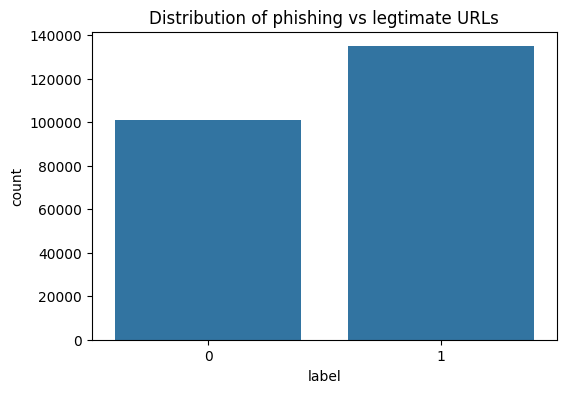

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df)
plt.title("Distribution of phishing vs legtimate URLs")
plt.show()

The plot shows the distribution of phishing and legitimate URLs in the dataset.

# URL Length Distribution (histplot)

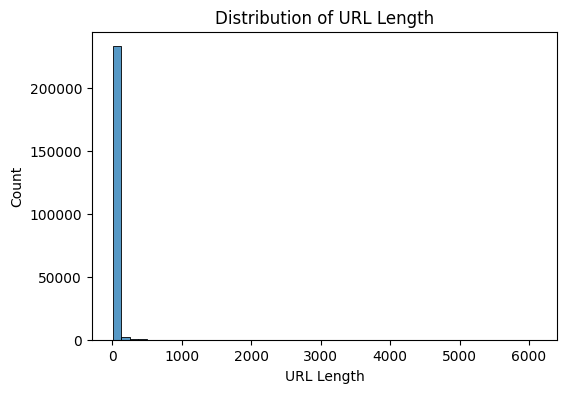

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["URLLength"], bins=50)
plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.show()

# Domain Length Boxplot (Outlier Detection)

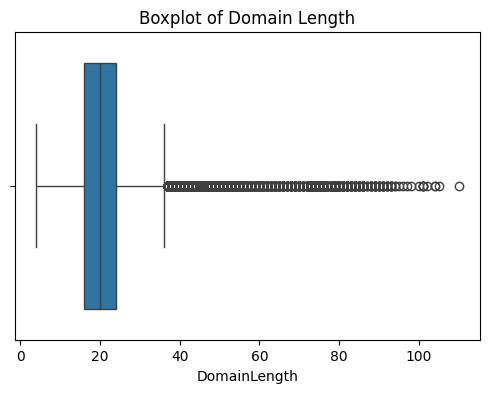

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["DomainLength"])
plt.title("Boxplot of Domain Length")
plt.show()

The boxplot reveals the presence of outliers, indicating some domains have unusually long names which may be characteristic of phishing URLs.

# URL Length vs Domain Length (Scatter Plot)

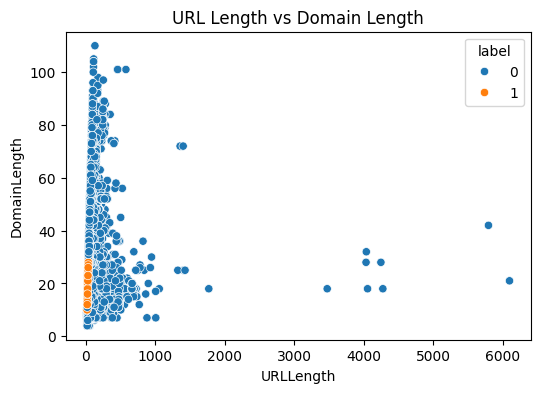

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="URLLength", y="DomainLength", hue="label", data=df)
plt.title("URL Length vs Domain Length")
plt.show()

The scatter plot shows how URL length relates to domain length. Some phishing URLs appear to have longer URL structures compared to legitimate ones

# Feature Correlation Heatmap

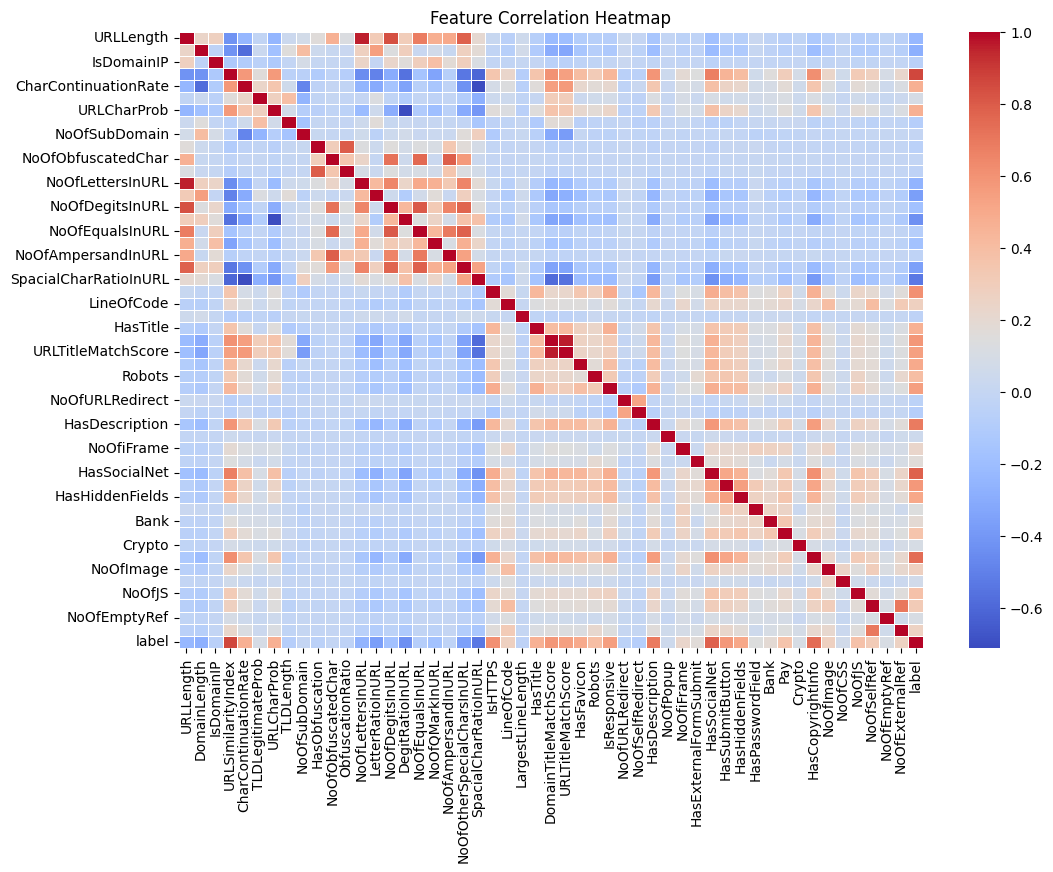

In [20]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", linewidths=0.7)

plt.title("Feature Correlation Heatmap")

plt.show()

The heatmap shows correlations among features. Highly correlated features may indicate redundancy and can be considered during preprocessing.

# Special Character Ratio Distribution

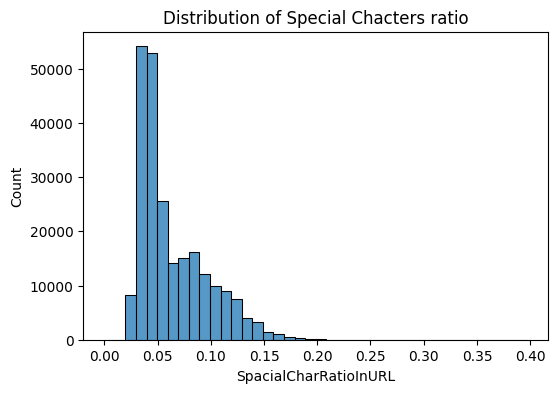

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["SpacialCharRatioInURL"],bins=40)
plt.title("Distribution of Special Chacters ratio")
plt.show()

Higher ratios of special characters may indicate suspicious URLs commonly used in phishing attacks

# Histogram of All numeric Features

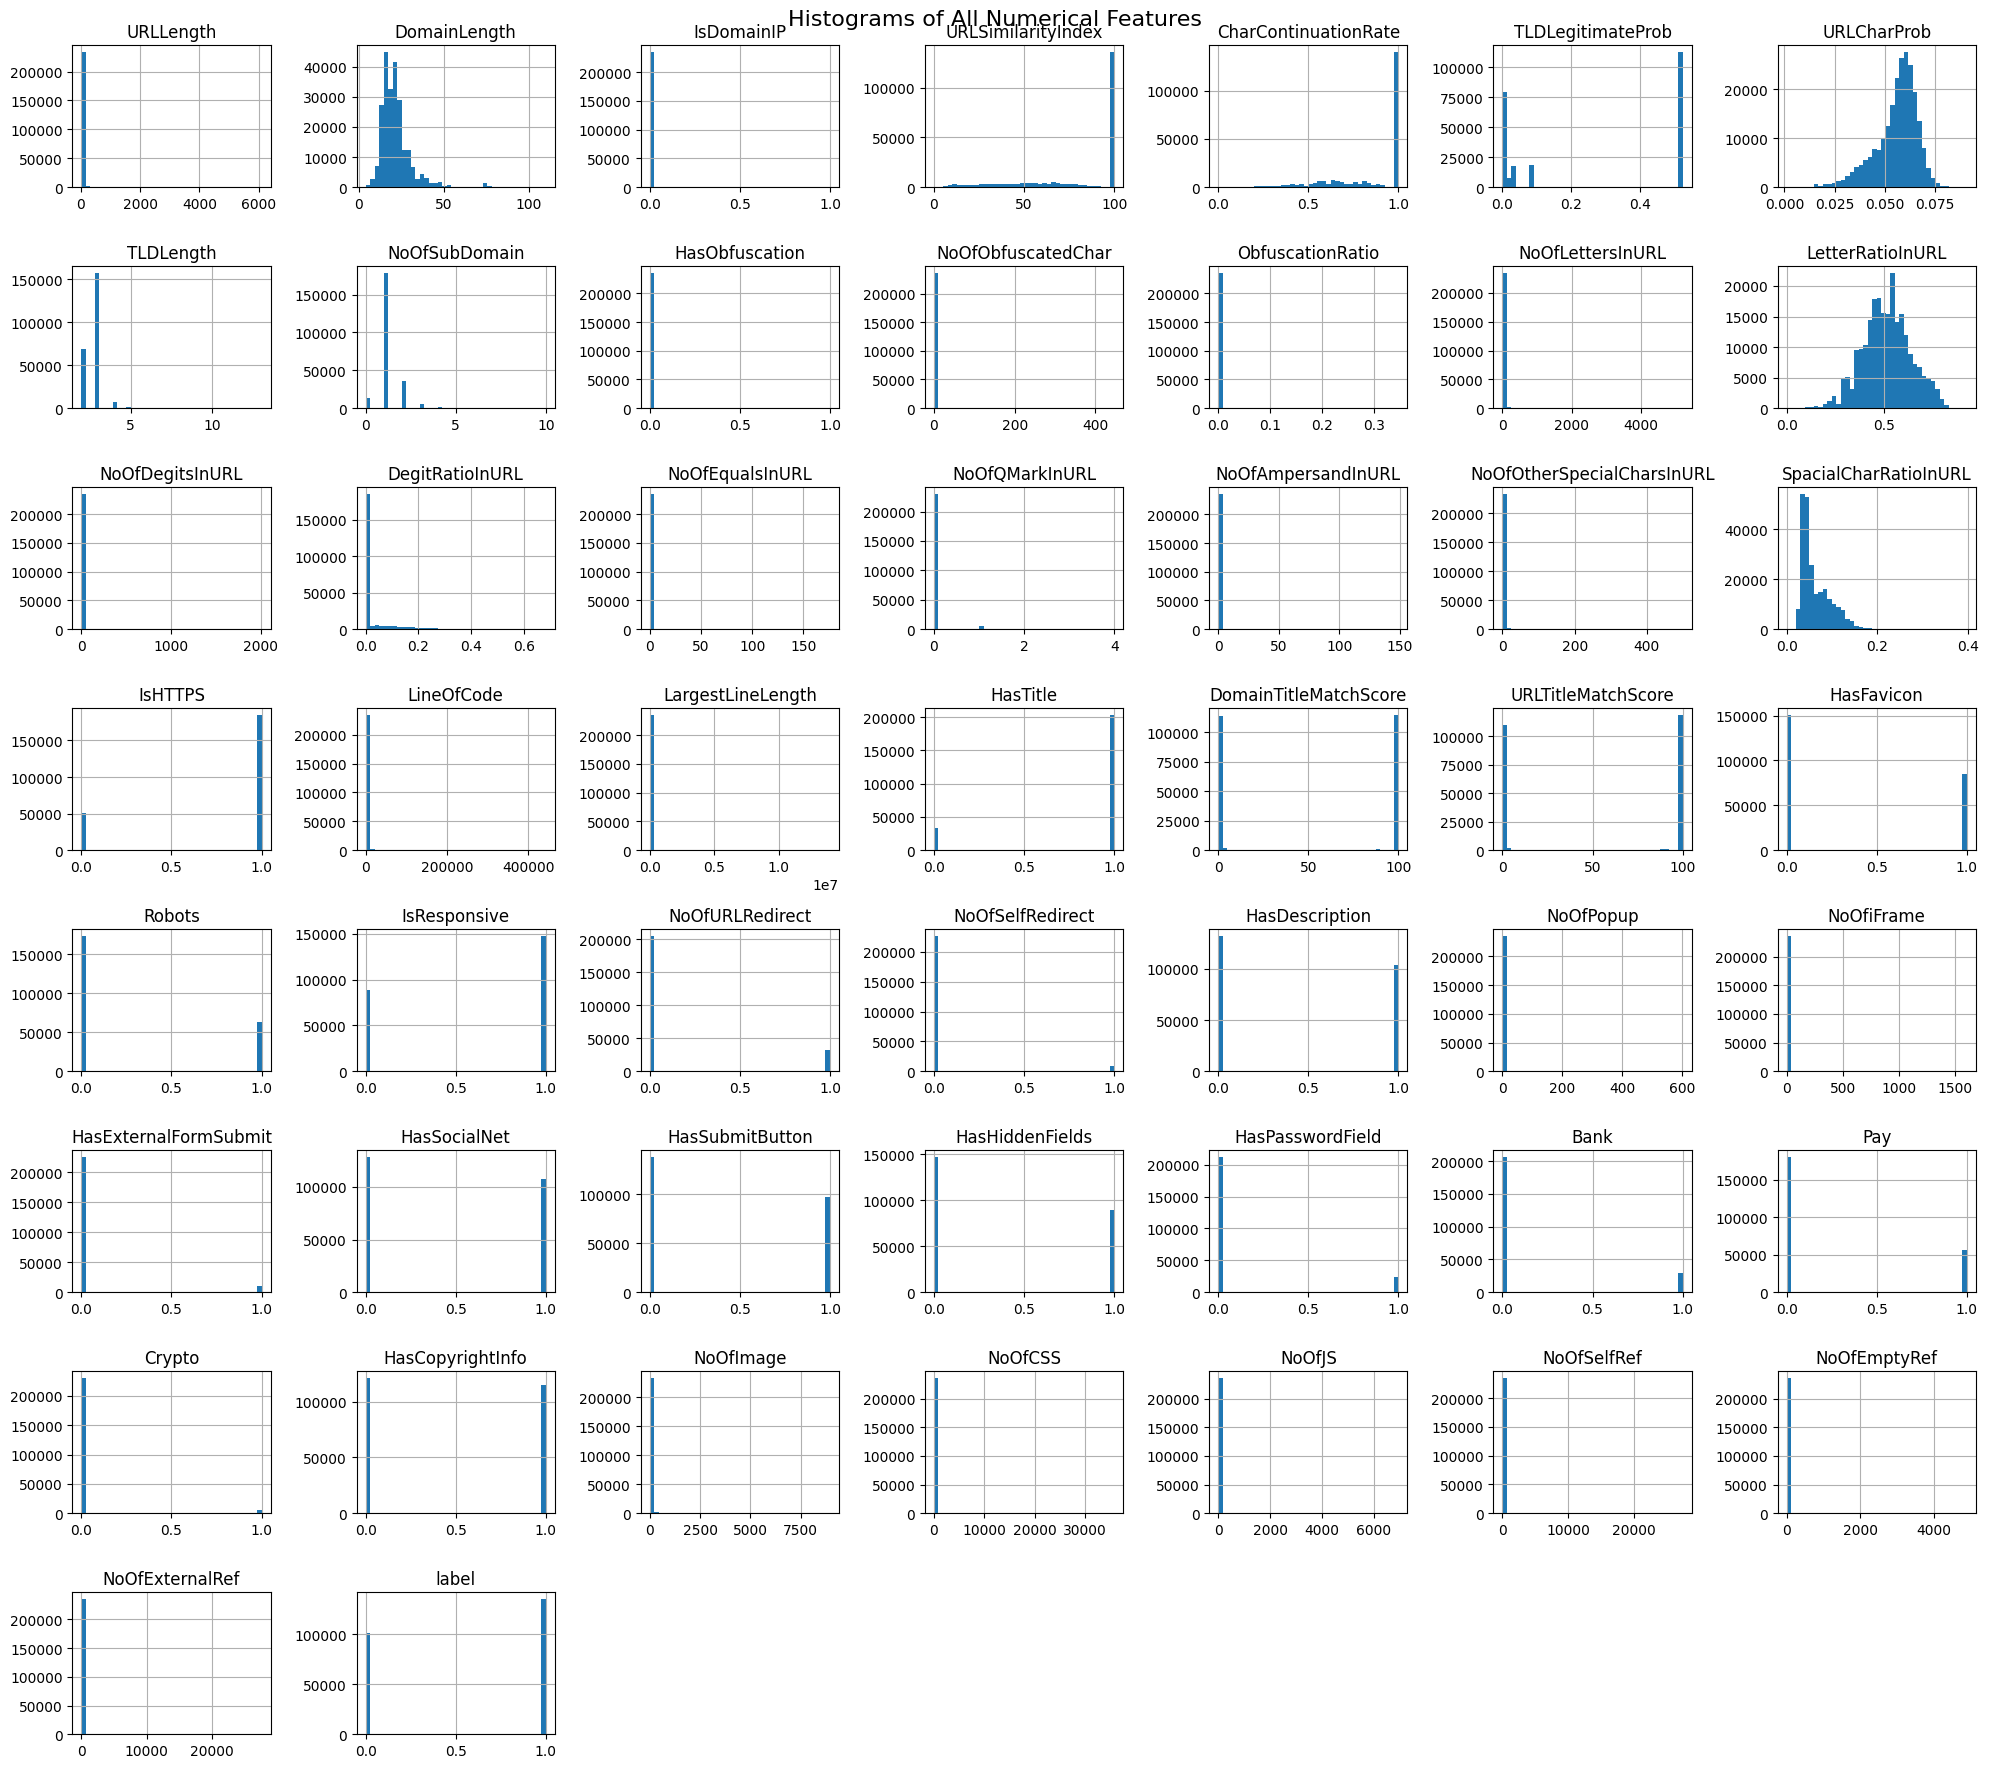

In [17]:
num_cols = df.select_dtypes(include=['int64','float64'])

# Plot histograms for all numeric features
num_cols.hist(figsize=(20,18), bins=40)

plt.suptitle("Histograms of All Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Automatically selects all numeric features

Creates histograms for each column

Displays them together in a grid

# Boxplot for All Numerical Columns

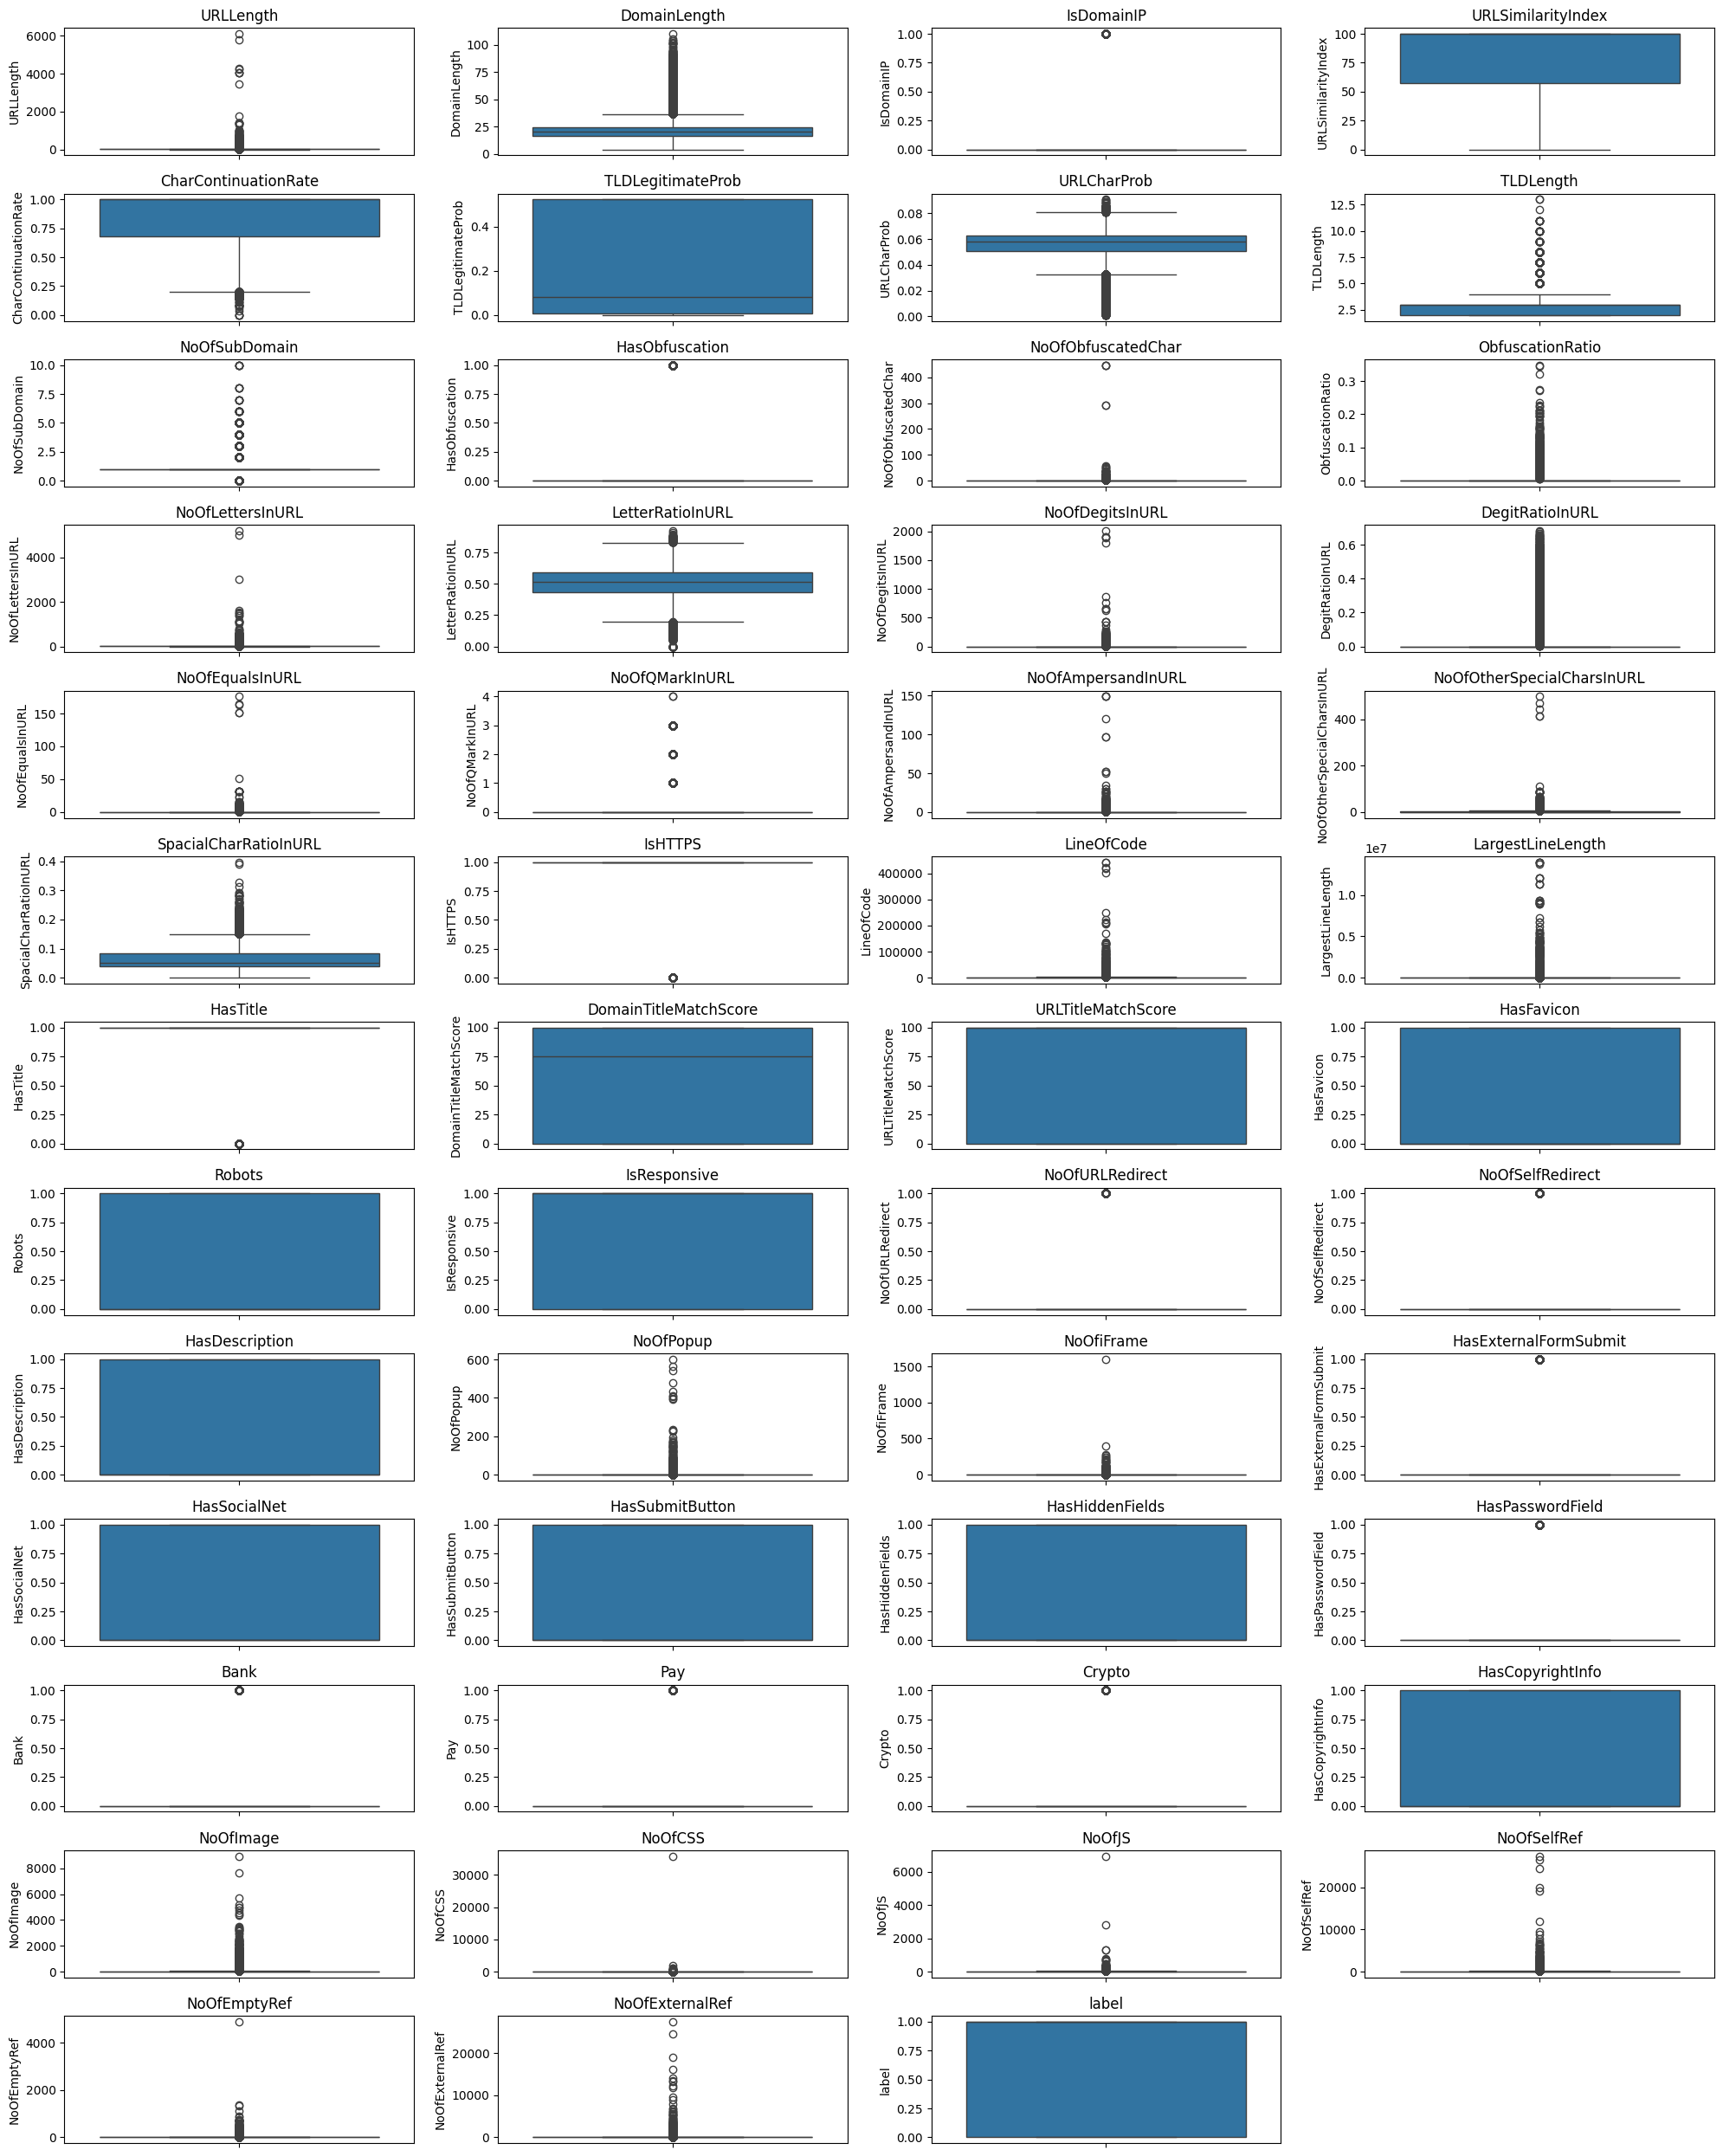

In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(20,25))

# Loop through columns
for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols)//4)+1, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Preprocessing
 # Drop irrelevant features

In [24]:

# Dropping raw text columns as they are too unique for standard ML models to learn from easily
df_clean = df.drop(columns=['URL', 'Domain', 'Title'])

Dropped URL, Domain, and Title because they are highly unique string identifiers that do not provide generalizable numerical patterns for the model.

# Encode Categorical Data

In [25]:

# Convert the TLD (Top Level Domain like .com, .org) into numerical dummy variables
df_clean = pd.get_dummies(df_clean, columns=['TLD'], drop_first=True)

Used one-hot encoding on the TLD feature so the machine learning model can process these categorical text values mathematically.

# Save the Dataset

In [28]:

df_clean.to_csv('preprocessed_phishing_dataset.csv', index=False)

# Select Only Numeric Columns

In [39]:
numeric_df = df.select_dtypes(include=['int64','float64'])

# Calculate Correlation with Target
This will show which features are most related to phishing detection.

In [40]:
corr = numeric_df.corr()["label"].abs().sort_values(ascending=False)
corr

label                         1.000000
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
SpacialCharRatioInURL         0.533537
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
DegitRatioInURL               0.432032
Robots                        0.392620
NoOfJS                        0.373500
LetterRatioInURL              0.367794
Pay                           0.359747
NoOfOtherSpecialCharsInURL    0.358891
NoOfSelfRef                   0.316211
DomainLength                  0.283152
NoOfImage                     0.274658
LineOfCode               

# Select Top 15 Features

In [41]:
top_features = corr[1:16].index   # ignore label itself
top_features

Index(['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo',
       'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton',
       'IsResponsive', 'URLTitleMatchScore', 'SpacialCharRatioInURL',
       'HasHiddenFields', 'HasFavicon', 'URLCharProb', 'CharContinuationRate',
       'HasTitle'],
      dtype='object')

# Create New Dataset with Important Features

The dataset originally contained 54 features. To reduce dimensionality and improve model efficiency, the top 15 most correlated features with the target variable were selected. Feature selection helps remove irrelevant or redundant features and improves model performance

In [42]:
df_selected = df[top_features.tolist() + ["label"]]
df_selected.head()

,URLSimilarityIndex,HasSocialNet,HasCopyrightInfo,HasDescription,IsHTTPS,DomainTitleMatchScore,HasSubmitButton,IsResponsive,URLTitleMatchScore,SpacialCharRatioInURL,HasHiddenFields,HasFavicon,URLCharProb,CharContinuationRate,HasTitle,label
0,100.0,0,1,0,1,0.000000,1,1,0.000000,0.032,1,0,0.061933,1.000000,1,1
1,100.0,1,1,0,1,55.555556,1,0,55.555556,0.087,0,1,0.050207,0.666667,1,1
2,100.0,0,1,1,1,46.666667,1,1,46.666667,0.069,1,0,0.064129,0.866667,1,1
3,100.0,1,1,0,1,0.000000,1,1,0.000000,0.038,1,0,0.057606,1.000000,1,1
4,100.0,1,1,1,1,100.000000,1,1,100.000000,0.030,1,0,0.059441,1.000000,1,1


# Apply Scaling on Selected Features

In [52]:
from sklearn.preprocessing import StandardScaler

X = df_selected.drop("label", axis=1)
y = df_selected["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine Dataset

In [54]:
processed_df = X_scaled
processed_df["label"] = y.values

# Save Processed Dataset

In [56]:
processed_df.to_csv("processed_phishing_dataset.csv", index=False)

# Visualize top feature correlations

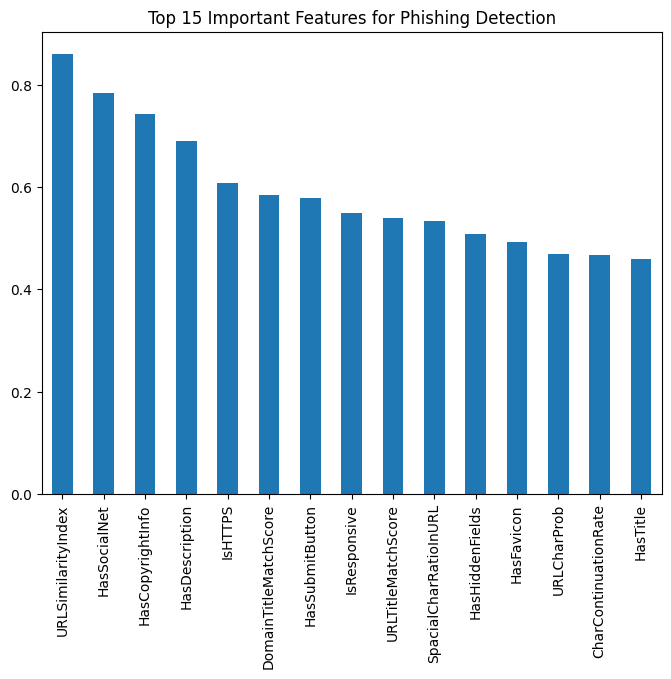

In [57]:
plt.figure(figsize=(8,6))
corr[1:16].plot(kind="bar")
plt.title("Top 15 Important Features for Phishing Detection")
plt.show()

The bar chart shows the most influential features affecting phishing detection

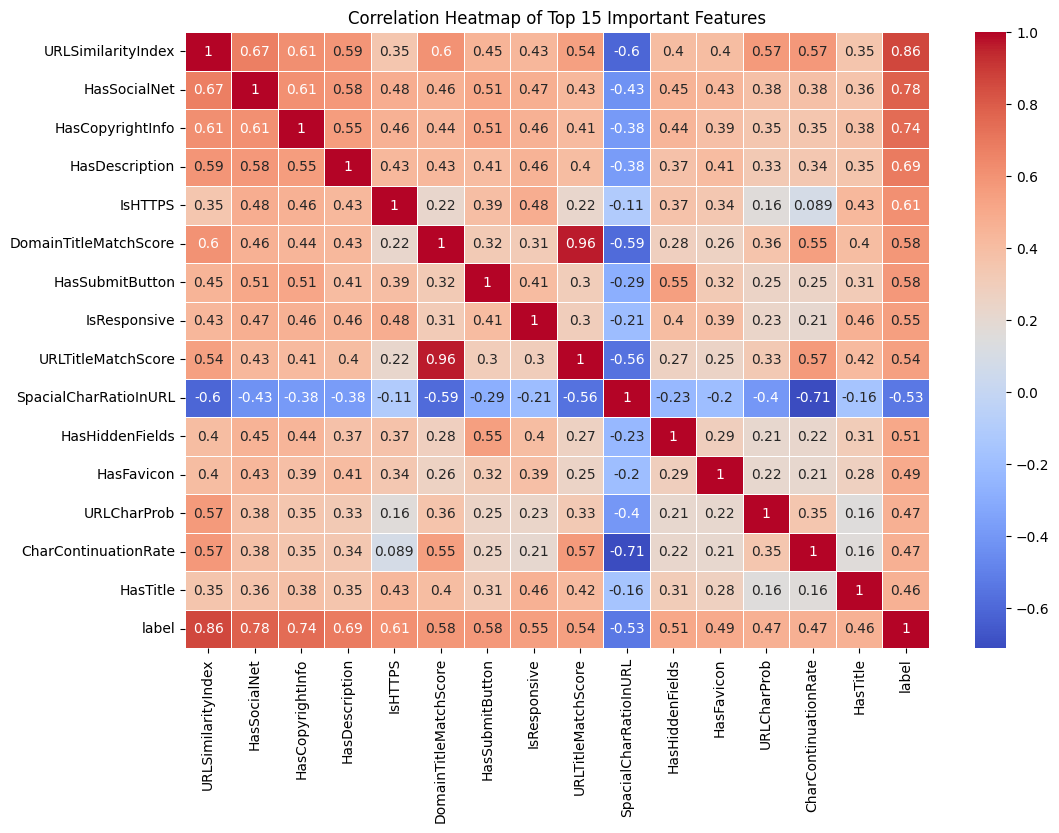

In [58]:
# Correlation matrix for selected features
corr_matrix = df_selected.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Top 15 Important Features")
plt.show()

The heatmap shows the correlation between the selected top 15 features and the target variable. Some features exhibit stronger relationships with the label, indicating their importance in detecting phishing URLs. This visualization also helps identify highly correlated features that may provide similar information.